# 手写数字识别 — KNN vs SVM 实战

**任务**：根据 28×28 灰度手写数字图片（784 个像素特征），预测其是 0~9 中的哪个数字（10 分类）
**核心目标**：在**同一份数据**上横向对比 **KNN（K 近邻）** 与 **SVM（支持向量机）** 两种经典分类算法，理解它们的原理差异与适用场景。

---

## 为什么这两个算法适合放一起？
- 都基于**样本在特征空间中的几何关系**（距离 / 超平面间隔）
- 都对**特征尺度敏感**，必须先做标准化
- 都不擅长**高维大样本**，所以本 notebook 使用 PCA 降维 + 子集采样来加速

## 建模步骤
1. 环境配置
2. 数据加载与概览
3. EDA（类别分布 + 样本可视化），归一化
4. 数据预处理（标准化 + PCA 降维）加速 KNN 与 SVM
5. KNN：不同 K 值对比
6. SVM：不同核函数对比
7. 模型对比与评估
8. 预测并生成提交文件


## 1. 环境配置


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)
print("环境配置完成")
print(f"当前工作目录: {os.getcwd()}")


环境配置完成
当前工作目录: e:\BaiduNetdiskDownload\Study_files\学习考证\Agent_Exercise\Kaggle_Competitions\Machine_learning\KNN_SVM_MNIST


In [2]:
# 兼容两种启动方式：MNIST-data（在本项目目录启动）或 KNN_SVM_MNIST/MNIST-data（在根目录启动）
DATA_DIR = "MNIST-data" if os.path.exists("MNIST-data") else os.path.join("KNN_SVM_MNIST", "MNIST-data")
assert os.path.exists(DATA_DIR), f"数据目录不存在: {DATA_DIR}"
print("数据文件:", sorted(os.listdir(DATA_DIR)))


数据文件: ['sample_submission.csv', 'test.csv', 'train.csv']


## 2. 数据加载与概览


In [3]:
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print(f"训练集形状: {train.shape}")   # 42000 行 × 785 列（label + 784 像素）
print(f"测试集形状: {test.shape}")    # 28000 行 × 784 列
print(f"提交样例形状: {sample_sub.shape}")

X = train.drop(columns=["label"])
y = train["label"]
X_test = test.copy()

print(f"特征数: {X.shape[1]}（28×28=784 像素）")
print(f"类别数: {y.nunique()}")
print(f"像素范围: {X.min().min()} ~ {X.max().max()}")


训练集形状: (42000, 785)
测试集形状: (28000, 784)
提交样例形状: (28000, 2)
特征数: 784（28×28=784 像素）
类别数: 10
像素范围: 0 ~ 255


## 3. EDA（类别分布 + 样本可视化）


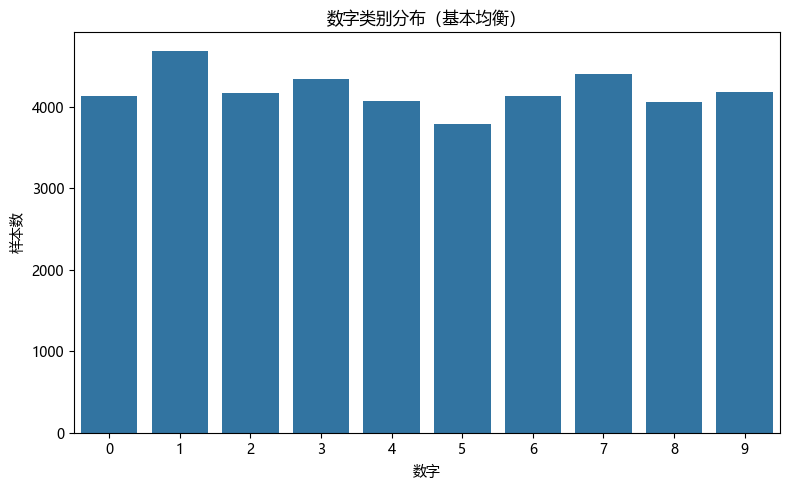

In [4]:
# ---- 数字类别分布 ----
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title("数字类别分布（基本均衡）")
plt.xlabel("数字")
plt.ylabel("样本数")
plt.tight_layout()
plt.show()


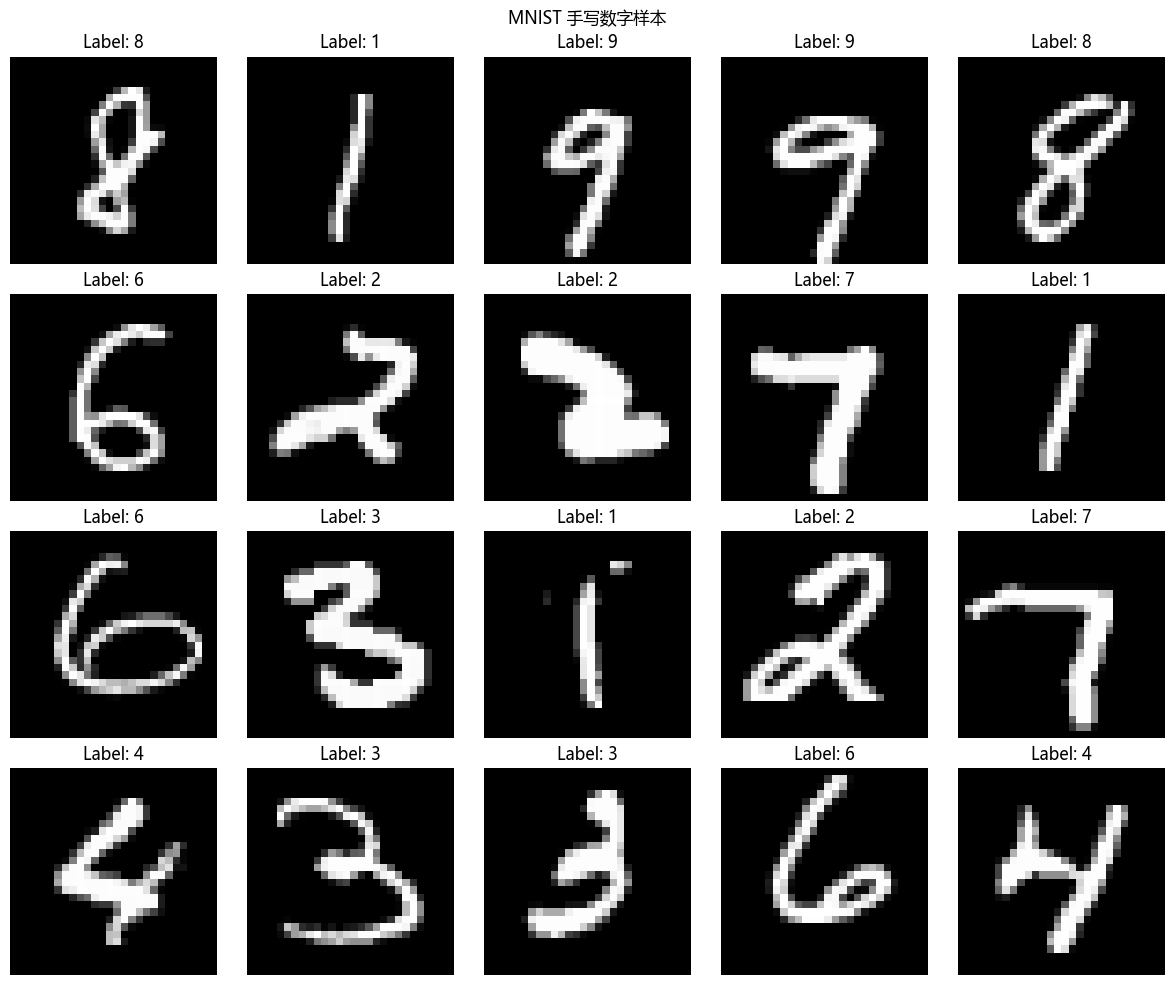

In [5]:
# ---- 随机展示 20 张样本图 ----
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.flatten()
sample_idx = np.random.choice(len(X), size=20, replace=False)
for i, idx in enumerate(sample_idx):
    img = X.iloc[idx].values.reshape(28, 28)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Label: {y.iloc[idx]}")
    axes[i].axis("off")
plt.suptitle("MNIST 手写数字样本")
plt.tight_layout()
plt.show()


## 4. 数据预处理（标准化 + PCA 降维）

**为什么必须标准化**：KNN 靠欧氏距离、SVM 靠内积，量纲差异会直接扭曲几何关系。
**为什么做 PCA**：784 维全量跑 KNN 极慢，PCA 保留 95% 方差（实际降至约 284 维），大幅加速且几乎不掉精度。


In [6]:
# ---- 抽子集加速实验（KNN 惰性学习，全量 42000 行预测会很慢） ----
# 分层抽样：8000 条训练 + 2000 条验证，保证每类比例一致
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, train_size=8000, test_size=2000, random_state=RANDOM_STATE, stratify=y
)

# ---- 标准化（只拟合训练集，防数据泄漏） ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test)

# ---- PCA 降维（只拟合训练集） ----
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train = pca.fit_transform(X_train_scaled)
X_val = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"实验训练集: {X_train.shape}, 验证集: {X_val.shape}")
print(f"训练集类别分布: \n{y_train.value_counts().sort_index().to_dict()}")
print(f"PCA 后特征数: {X_train.shape[1]}（原 784 维）")
print(f"保留方差比例: {pca.explained_variance_ratio_.sum():.2%}")


实验训练集: (8000, 284), 验证集: (2000, 284)
训练集类别分布: 
{0: 787, 1: 892, 2: 795, 3: 829, 4: 776, 5: 723, 6: 788, 7: 838, 8: 774, 9: 798}
PCA 后特征数: 284（原 784 维）
保留方差比例: 95.01%


## 5. KNN：不同 K 值对比


K=1: 验证集准确率=0.9040
K=3: 验证集准确率=0.9080
K=5: 验证集准确率=0.9075
K=7: 验证集准确率=0.9110
K=9: 验证集准确率=0.9070


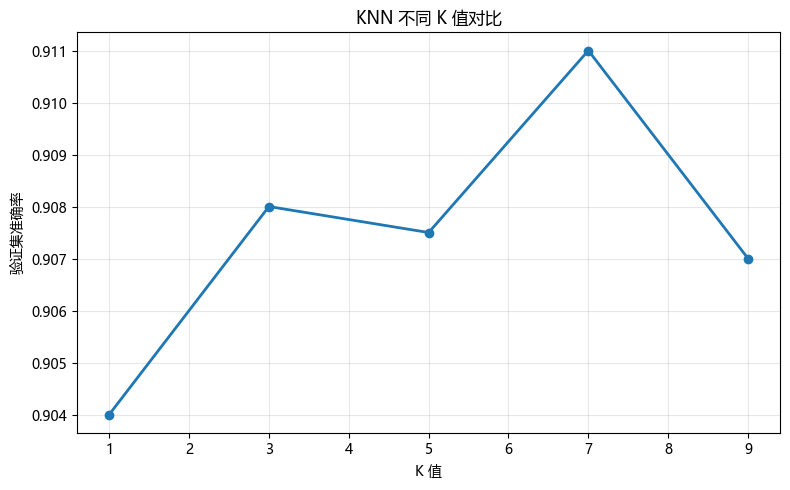

最佳 K 值: 7（准确率=0.9110）


In [7]:
# ---- KNN 不同 K 值对比（K=1,3,5,7,9） ----
k_values = [1, 3, 5, 7, 9]
knn_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_val, knn.predict(X_val))
    knn_results[k] = acc
    print(f"K={k}: 验证集准确率={acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, list(knn_results.values()), "o-", lw=2)
plt.xlabel("K 值"); plt.ylabel("验证集准确率")
plt.title("KNN 不同 K 值对比")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_k = max(knn_results, key=knn_results.get)
print(f"最佳 K 值: {best_k}（准确率={knn_results[best_k]:.4f}）")


## 6. SVM：不同核函数对比

SVM 通过核函数把样本映射到高维空间找最大间隔超平面：
- **linear（线性核）**：数据线性可分时高效
- **rbf（高斯径向基核）**：最常用，能处理非线性边界
- **poly（多项式核）**：适合有明确多项式关系的数据


SVM-linear   验证集准确率=0.9030
SVM-rbf      验证集准确率=0.9385
SVM-poly     验证集准确率=0.9025


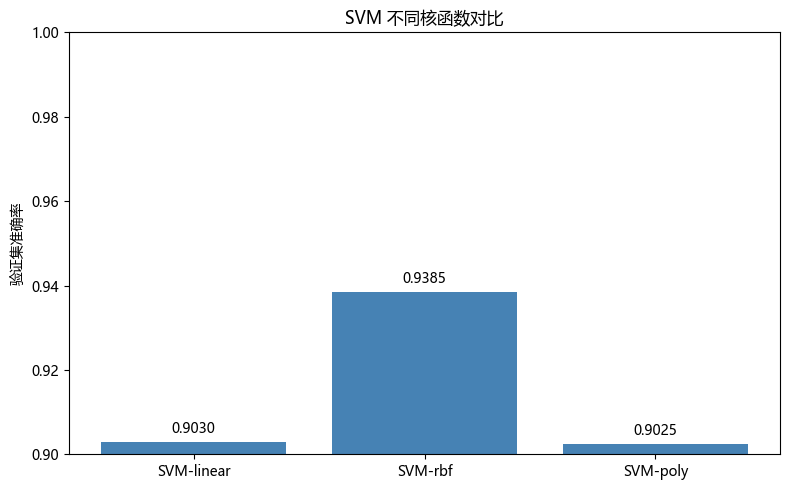

In [8]:
# ---- SVM 不同核函数对比 ----
svm_models = {
    "SVM-linear": SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE),
    "SVM-rbf":    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
    "SVM-poly":   SVC(kernel="poly", degree=3, C=1.0, random_state=RANDOM_STATE),
}

svm_results = {}
for name, clf in svm_models.items():
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_val, clf.predict(X_val))
    svm_results[name] = acc
    print(f"{name:12s} 验证集准确率={acc:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(svm_results.keys(), svm_results.values(), color="steelblue")
plt.ylim(0.9, 1.0)
plt.ylabel("验证集准确率")
plt.title("SVM 不同核函数对比")
for i, (k, v) in enumerate(svm_results.items()):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.show()


## 7. 模型对比与评估


In [9]:
# ---- 汇总对比表 ----
comparison = pd.DataFrame(
    {
        "验证集准确率": list(knn_results.values()) + list(svm_results.values()),
    },
    index=[f"KNN(K={k})" for k in knn_results] + list(svm_results.keys()),
).round(4).sort_values("验证集准确率", ascending=False)
comparison


,验证集准确率
SVM-rbf,0.9385
KNN(K=7),0.9110
KNN(K=3),0.9080
KNN(K=5),0.9075
KNN(K=9),0.9070
KNN(K=1),0.9040
SVM-linear,0.9030
SVM-poly,0.9025


最佳模型: SVM-rbf


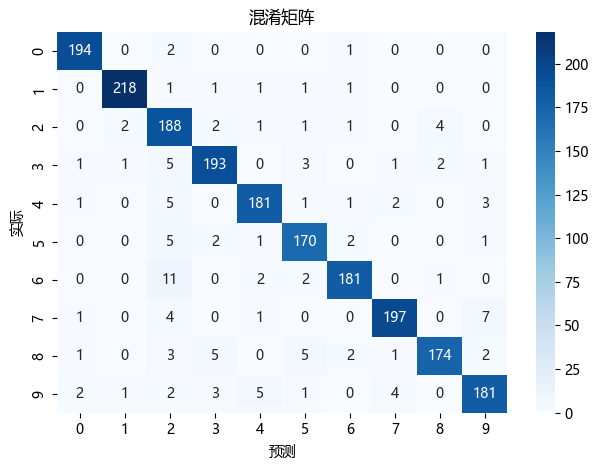

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       197
           1       0.98      0.98      0.98       223
           2       0.83      0.94      0.88       199
           3       0.94      0.93      0.93       207
           4       0.94      0.93      0.94       194
           5       0.92      0.94      0.93       181
           6       0.96      0.92      0.94       197
           7       0.96      0.94      0.95       210
           8       0.96      0.90      0.93       193
           9       0.93      0.91      0.92       199

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



In [10]:
# ---- 最佳模型：混淆矩阵 + 分类报告 ----
best_name = comparison.index[0]
if best_name.startswith("KNN"):
    k = int(best_name.split("(")[1].split(")")[0])
    best_model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
else:
    best_model = svm_models[best_name]
best_model.fit(X_train, y_train)
y_val_pred = best_model.predict(X_val)

print(f"最佳模型: {best_name}")

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.title("混淆矩阵")
plt.xlabel("预测"); plt.ylabel("实际")
plt.tight_layout()
plt.show()

print(classification_report(y_val, y_val_pred))


## 8. 预测并生成提交文件


In [11]:
# ---- 用最佳模型预测测试集 ----
test_pred = best_model.predict(X_test_pca)

submission = pd.DataFrame({
    "ImageId": np.arange(1, len(test_pred) + 1),
    "Label": test_pred,
})
submission.head()


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,4
4,5,3


In [12]:
submission_path = os.path.join(DATA_DIR, "submission.csv")
submission.to_csv(submission_path, index=False)
print(f"已保存提交文件: {submission_path}")
print(f"提交行数: {len(submission)}（应与 sample_submission 一致 = {len(sample_sub)}）")


已保存提交文件: MNIST-data\submission.csv
提交行数: 28000（应与 sample_submission 一致 = 28000）


In [13]:
print("=" * 60)
print("MNIST KNN vs SVM 项目完成！")
print("=" * 60)
print(f"  最佳模型      : {best_name}")
print(f"  验证集准确率  : {comparison.iloc[0, 0]:.4f}")
print(f"  提交文件      : {submission_path}")
print("=" * 60)
print("\n结论要点：")
print("  - KNN 简单直观，K 值过大/过小都会影响效果")
print("  - SVM 配合 RBF 核在 MNIST 上通常优于 KNN")
print("  - 两者都依赖标准化，PCA 能大幅加速 KNN")


MNIST KNN vs SVM 项目完成！
  最佳模型      : SVM-rbf
  验证集准确率  : 0.9385
  提交文件      : MNIST-data\submission.csv

结论要点：
  - KNN 简单直观，K 值过大/过小都会影响效果
  - SVM 配合 RBF 核在 MNIST 上通常优于 KNN
  - 两者都依赖标准化，PCA 能大幅加速 KNN
